<br/>

<div align="center">
<span style="font-size: 2.5em;">Halo Model Comparison: Realistic Scenarios for S1S2</span>
<br/>
<span style="font-size: 1.2em; color: gray;">Testing combined posteriors with realistic halo models (SHM, SHMpp, LMC)</span>
</div>

## Overview

This notebook tests the method with **realistic halo models** (SHM, SHMpp, LMC) and their combined posterior for the S1S2 representation of the data.

In [ ]:
# =============================
# IMPORTS AND PATH SETTINGS
# =============================

import os
desired_root_name = "dark-matter-sbi" 
while os.path.basename(os.getcwd()) != desired_root_name:
    os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Project imports
from configs.config import load_halo_models_s1s2, PARAM_RANGES
from utils.posteriors import posterior_halo_comparison_s1s2
from utils.processing import clean_nan_events, SignalPlusBackgroundDataset, filter_by_parameter_ranges
from performances.metrics import (
    coverage_comparison_s1s2,
    model_performances_s1s2,
    compare_metric_histograms,
)

In [ ]:
# ===========================================
# PARAMETERS TO DEFINE THE DATA AND MODEL 
# ===========================================

modelname = "hist_s1s2"                
n_train   = 300_000
halos = ["default", "shm", "shmpp", "lmc"]
halo_choice = "default"             # Reference halo for metrics normalization
bins = 20                       # S1-S2 histogram bins per dimension
mu_bkg = 150                      # Expected background events (0 = signal only)
training_mode = "online"       # Training approach: "offline" or "online"

# Derived parameters
signal_type = "signal_only" if mu_bkg == 0 else f"signal_bkg_mu{mu_bkg:.0f}"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =============================
# LOAD MODELS
# =============================

models, labels = load_halo_models_s1s2(
    halos=halos,
    modelname=modelname,
    n_train=n_train,
    bins=bins,
    mu_bkg=mu_bkg,
    training_mode=training_mode,
    device=device,
)

Configuration:
  Model: hist_s1s2, Bins: 20x20
  Training: 300,000 samples (online)
  Halos: ['default', 'shm', 'shmpp', 'lmc']
  Reference halo: default
  Background: 150 ERs (signal_bkg_mu150)
  Device: cpu


## 0. Load Data

Load S1-S2 validation data and create histograms with signal + background.

In [4]:
# ==========================================================
# Load S1-S2 validation data
# ==========================================================

print(f"Loading S1-S2 data for halo: {halo_choice}")

# Load signal spectra
signal_data = torch.load(
    f"data/datasets/xenon/s1s2/pt/s1s2_n{n_train}_{halo_choice}.pt",
    weights_only=False
)
energies_list = signal_data["events"]
cs1cs2_list = signal_data["cs1cs2"]
theta_list = signal_data["theta"]
print(f"  Loaded {len(theta_list):,} signal spectra")

# Clean NaN events
energies_list, cs1cs2_list = clean_nan_events(energies_list, cs1cs2_list)

# Split into validation set (80/20 split, using test portion)
_, cs1cs2_val, _, theta_val = train_test_split(
    cs1cs2_list, theta_list, test_size=0.2, random_state=42, shuffle=True
)
print(f"  Validation set: {len(theta_val):,} spectra")

# Load background events
bkg_events = np.loadtxt(
    "data/datasets/xenon/s1s2/ers/s1s2_ers.csv",
    delimiter=",", skiprows=1, usecols=(0, 1)
)
print(f"  Background events: {len(bkg_events):,}")

# Create dataset that generates S1-S2 histograms with signal + background
val_dataset = SignalPlusBackgroundDataset(
    signal_events=cs1cs2_val,
    theta=theta_val,
    background_events=bkg_events,
    mu_bkg=mu_bkg,
    s1_bins=bins,
    s2_bins=bins,
    reproducible=True,
    rng_seed=42,
)
print(f"\nValidation S1-S2 dataset created: {len(val_dataset)} samples")

# Convert validation dataset to tensors for all analyses
X_val = []
T_val = []

for i in range(len(val_dataset)):
    x, t = val_dataset[i]
    X_val.append(x.flatten())
    T_val.append(t)

X_val_tensor = torch.stack(X_val)
T_val_tensor = torch.stack(T_val)
print(f"  Prepared validation tensors: X shape {X_val_tensor.shape}, T shape {T_val_tensor.shape}")

Loading S1-S2 data for halo: default
  Loaded 300,000 signal spectra
  Validation set: 60,000 spectra
  Background events: 9,027,194

Validation S1-S2 dataset created: 60000 samples
  Prepared validation tensors: X shape torch.Size([60000, 400]), T shape torch.Size([60000, 2])


## 1. Qualitative Posterior Comparison

Visualize posteriors from different halo models for individual S1-S2 histogram samples to build intuition for model differences.

In [5]:
# ==========================================================
# Wrapper for posterior comparison
# ==========================================================

def run_posterior_comparison(m, cp, halo_choice, models, labels):
    posterior_halo_comparison_s1s2(
        mchi_true=m,
        cp_true=cp,
        halo_choice=halo_choice,
        models=models,
        labels=labels,
        X_test=X_val_tensor,
        T_test=T_val_tensor,
        logm_range=(0,3),
        logcp_range=(-10.5, -8.5),
        device=device,
        posteriorbins=100,
        levels=50,
    )

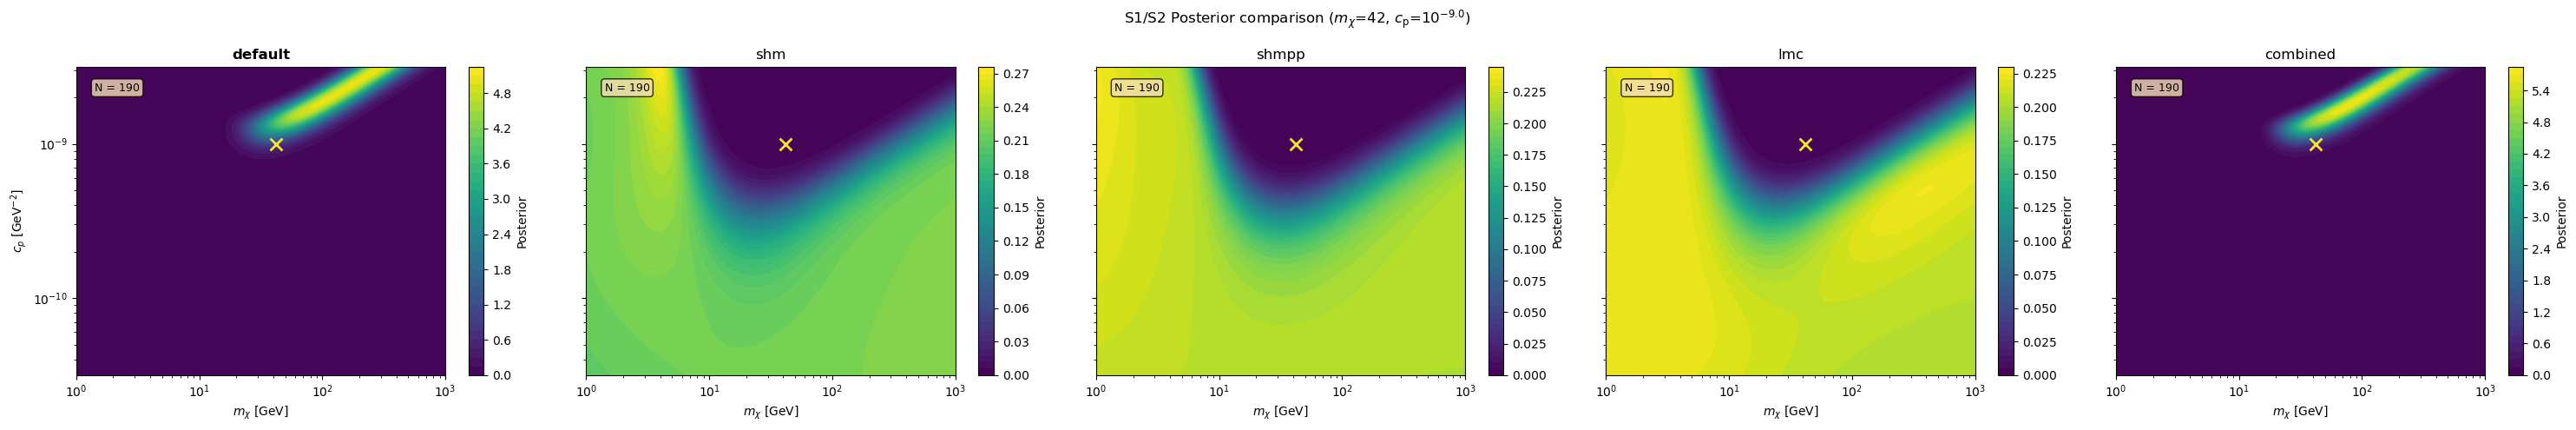

In [6]:
run_posterior_comparison(m=42, cp=10**(-9.0), halo_choice=halo_choice, models=models, labels=labels)

## 2. Coverage Analysis

Running coverage tests on full parameter space...

Total test samples: 60000
Running coverage test for: default
Running coverage test for: shm
Running coverage test for: shmpp
Running coverage test for: lmc
Running coverage test for: combined


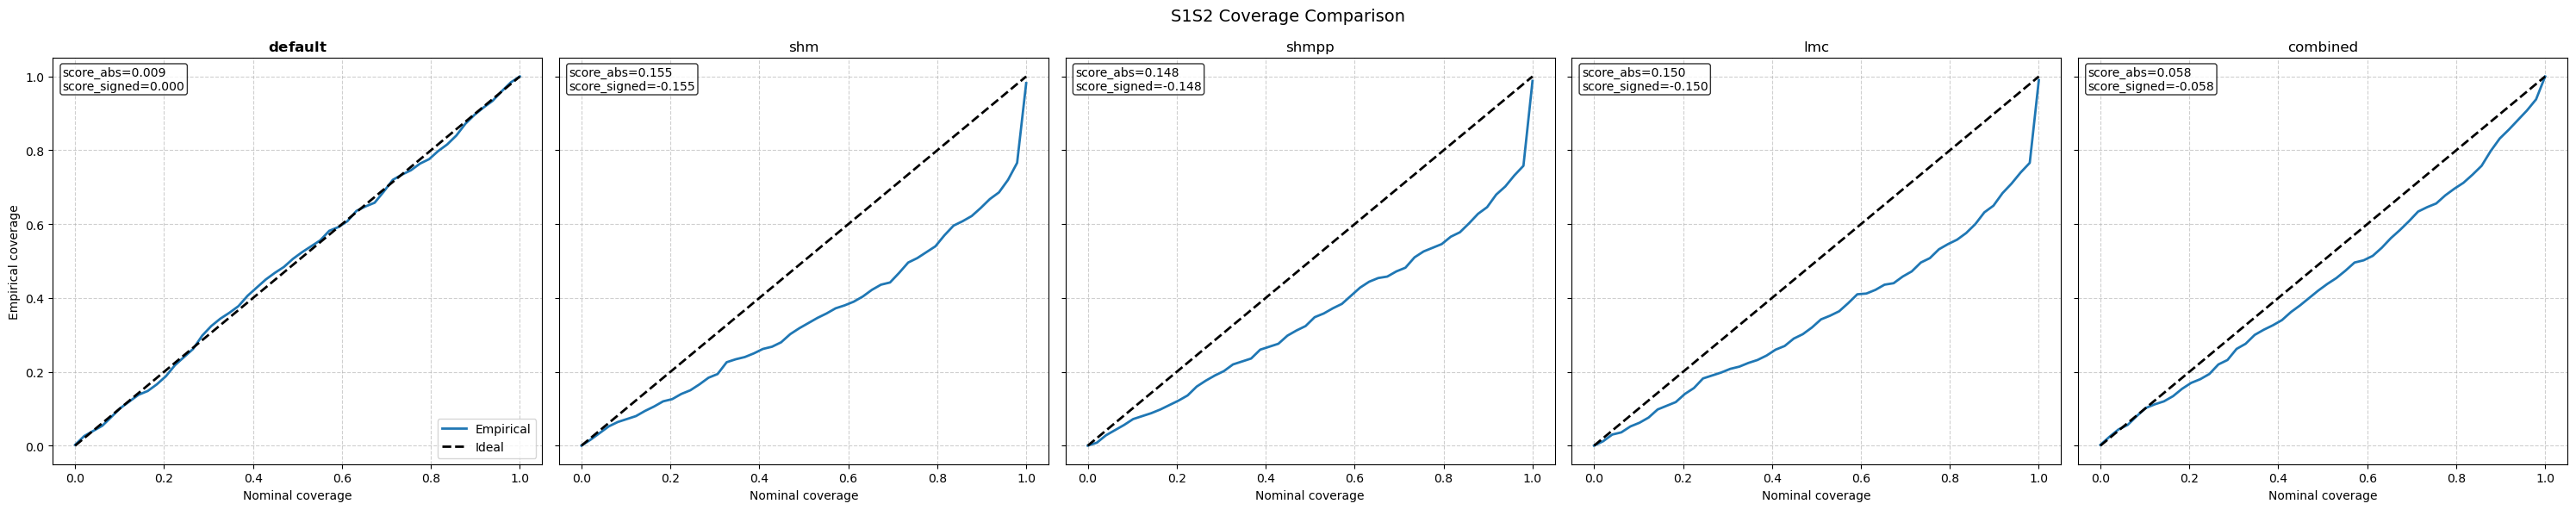

In [7]:
# ==========================================================
# Coverage comparison: Full parameter space
# ==========================================================

print("Running coverage tests on full parameter space...\n")

coverage_comparison_s1s2(
    models=models,
    labels=labels,
    halo_choice=halo_choice,
    X_test=X_val_tensor,
    T_test=T_val_tensor,
    logm_range=(0,3),
    logcp_range=(-10.5, -8.5),
    device=device,
    posteriorbins=100,
    levels=np.linspace(0, 1, 50),
    n_samples=min(500, len(X_val_tensor)),
)

### Focused Parameter Region

Running coverage tests in focused parameter region...

Filtered test samples: 10917
Running coverage test for: default
Running coverage test for: shm
Running coverage test for: shmpp
Running coverage test for: lmc
Running coverage test for: combined


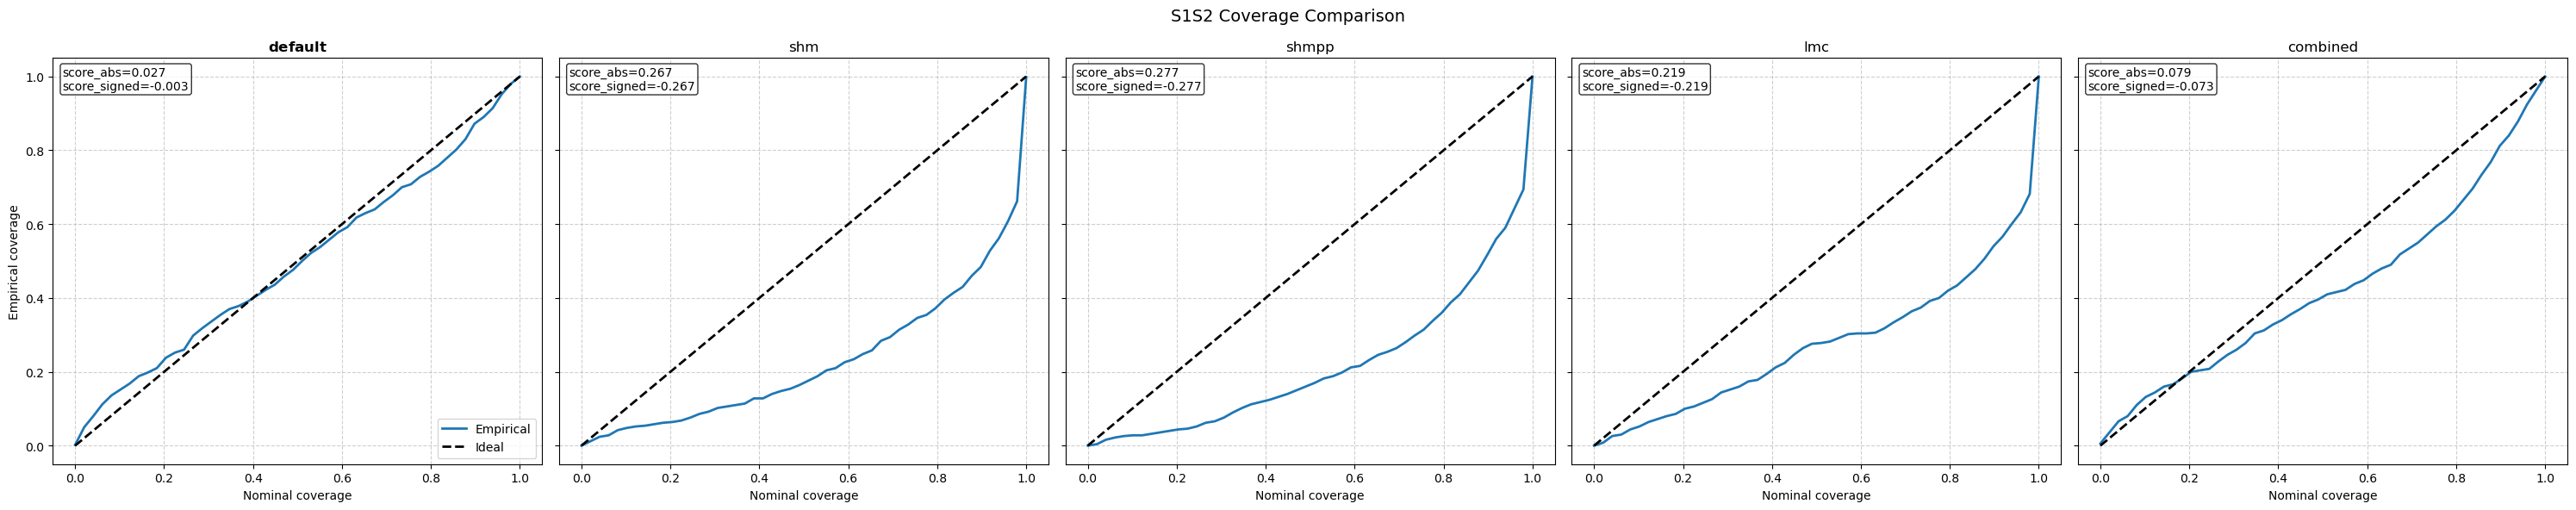

In [8]:
# ==========================================================
# Coverage comparisons in a smaller parameter space
# ==========================================================

print("Running coverage tests in focused parameter region...\n")

coverage_comparison_s1s2(
    models=models,
    labels=labels,
    halo_choice=halo_choice,
    X_test=X_val_tensor,
    T_test=T_val_tensor,
    logm_range=(0,3),
    logcp_range=(-10.5, -8.5),
    device=device,
    posteriorbins=100,
    levels=np.linspace(0, 1, 50),
    n_samples=min(500, len(X_val_tensor)),
    logm_window=(np.log10(5), np.log10(30)),
    logcp_window=(-10, -8.6)
)

## 3. Accuracy & Precision Metrics

Computing performance metrics (full parameter space)...

Non-zero test samples: 60000 / 60000
Evaluating model: default
Evaluating model: shm
Evaluating model: shmpp
Evaluating model: lmc
Evaluating model: combined


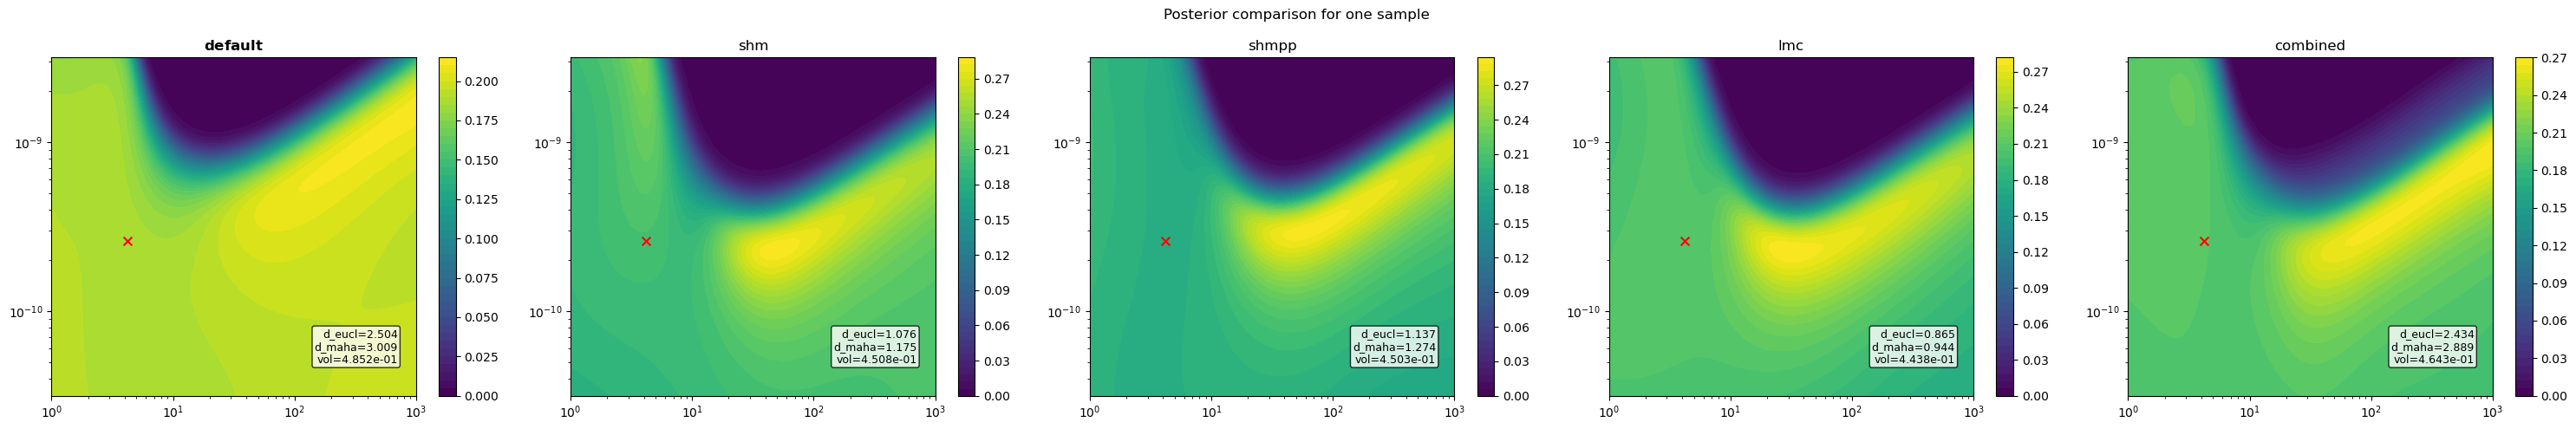

In [9]:
# ==========================================================
# Compute performance metrics (full parameter space)
# ==========================================================

print("Computing performance metrics (full parameter space)...\n")

performances = model_performances_s1s2(
    models=models,
    labels=labels,
    halo_choice=halo_choice,
    X_test=X_val_tensor,
    T_test=T_val_tensor,
    logm_range=(0,3),
    logcp_range=(-10.5, -8.5),
    device=device,
    posteriorbins=100,
    n_samples=min(500, len(X_val_tensor)),
    plotting=True,
    plotting_index=17
)

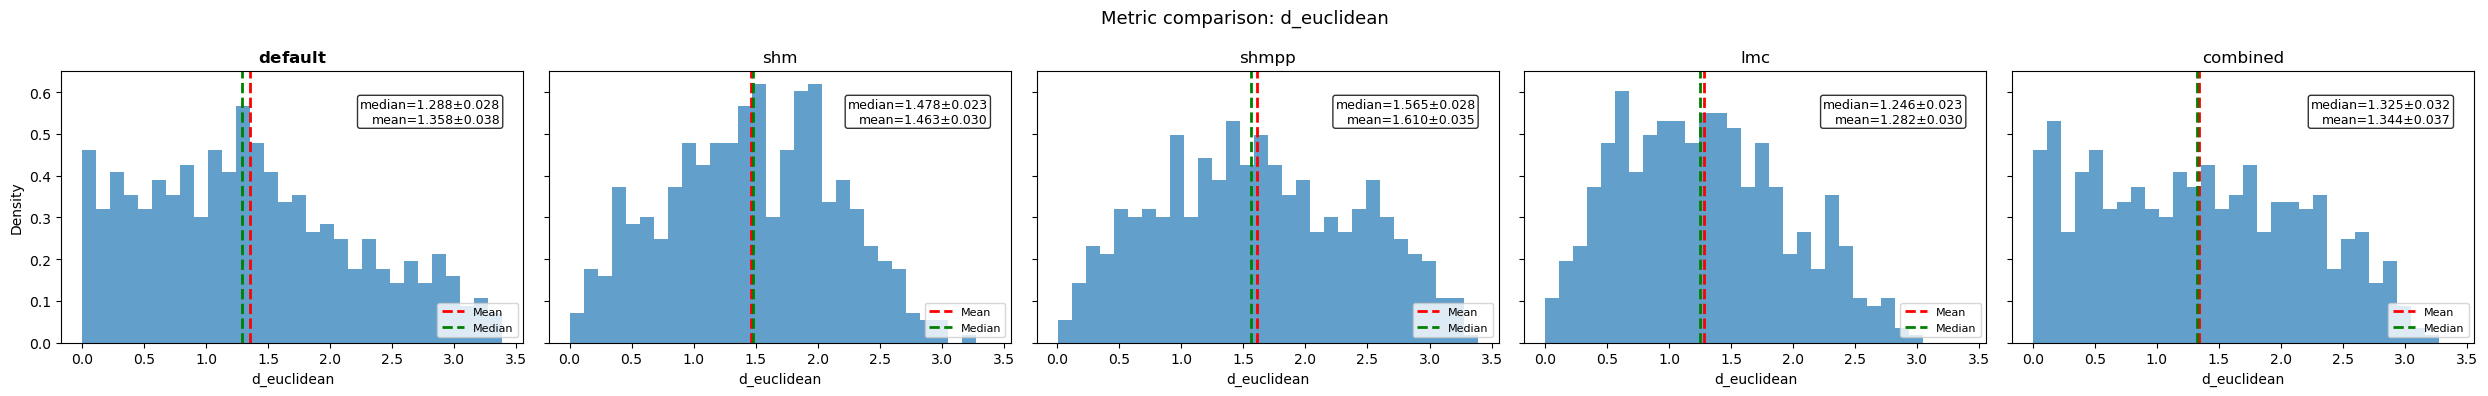

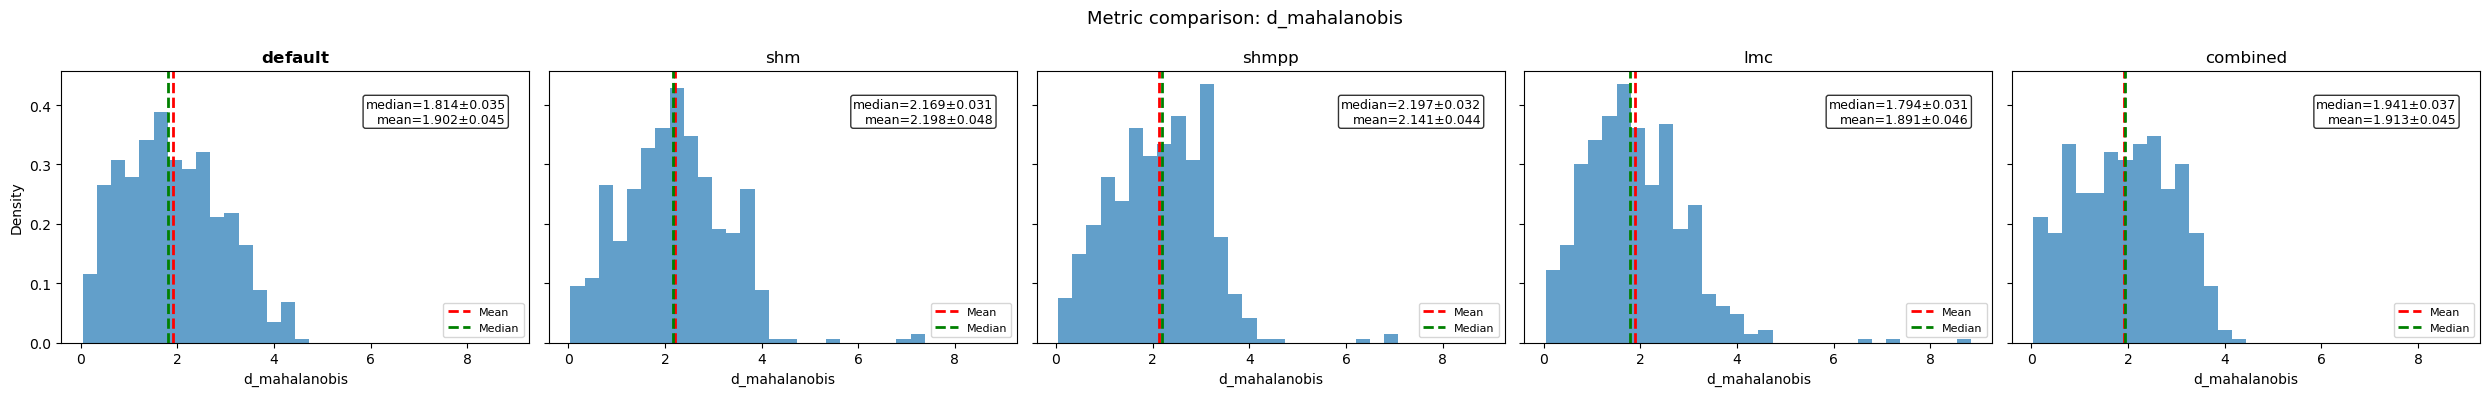

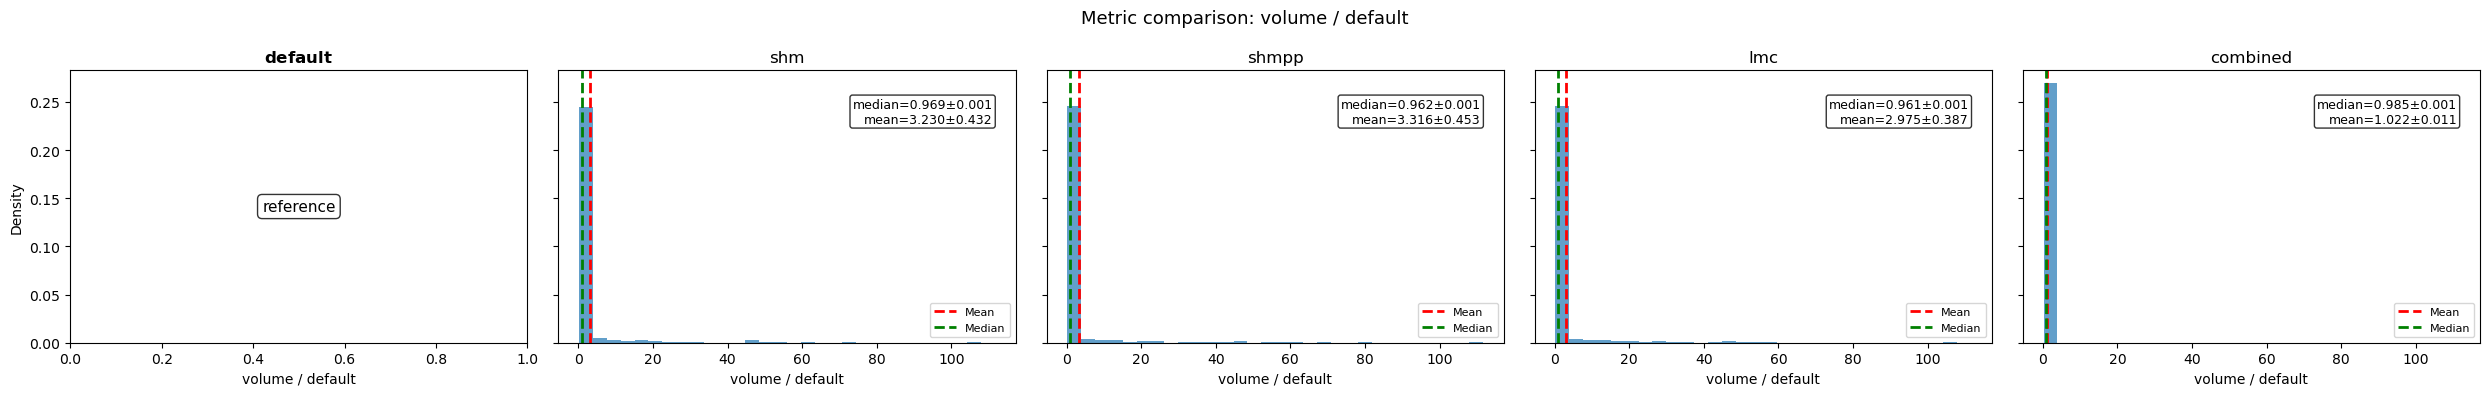

In [10]:
for metric in ["d_euclidean", "d_mahalanobis", "volume"]:
    compare_metric_histograms(
        performances,
        metric=metric,
        bins=30,
        reference_label=halo_choice,
    )

### Focused Parameter Window

In [11]:
# ==========================================================
# Compute performance metrics (focused parameter window)
# ==========================================================

print("Computing performance metrics (focused parameter window)...\n")

# Filter validation data to focused window
X_windowed, T_windowed = filter_by_parameter_ranges(
    T=T_val_tensor,
    X=X_val_tensor,
    logm_window=(np.log10(5), np.log10(30)),
    logcp_window=(-10, -8.6),
)
print(f"Samples in focused window: {len(T_windowed)} / {len(T_val_tensor)}\n")

performances_windowed = model_performances_s1s2(
    models=models,
    labels=labels,
    halo_choice=halo_choice,
    X_test=X_windowed,
    T_test=T_windowed,
    logm_range=(0,3),
    logcp_range=(-10.5, -8.5),
    device=device,
    posteriorbins=100,
    n_samples=min(500, len(X_windowed)),
)


Computing performance metrics (focused parameter window)...

Samples in focused window: 10917 / 60000

Non-zero test samples: 10917 / 10917
Evaluating model: default
Evaluating model: shm
Evaluating model: shmpp
Evaluating model: lmc
Evaluating model: combined


Comparing metric distributions (focused window)...



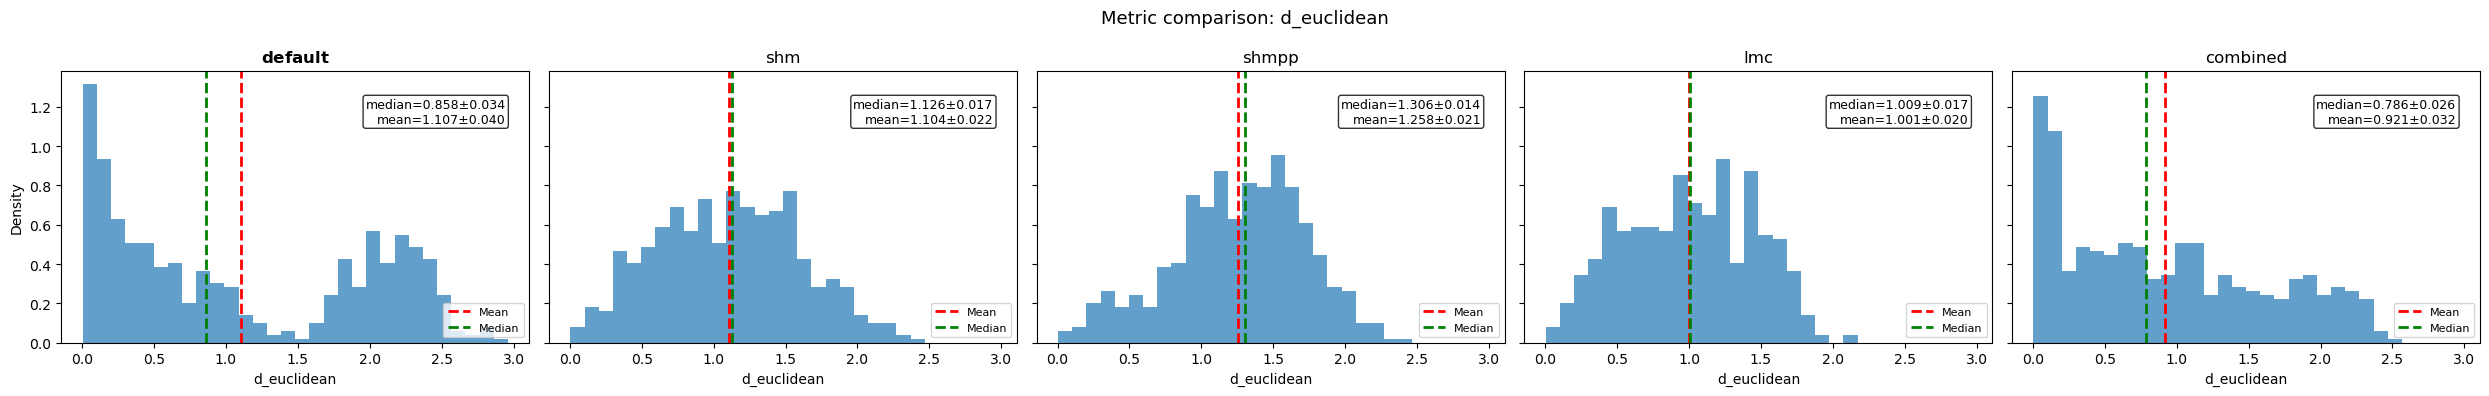

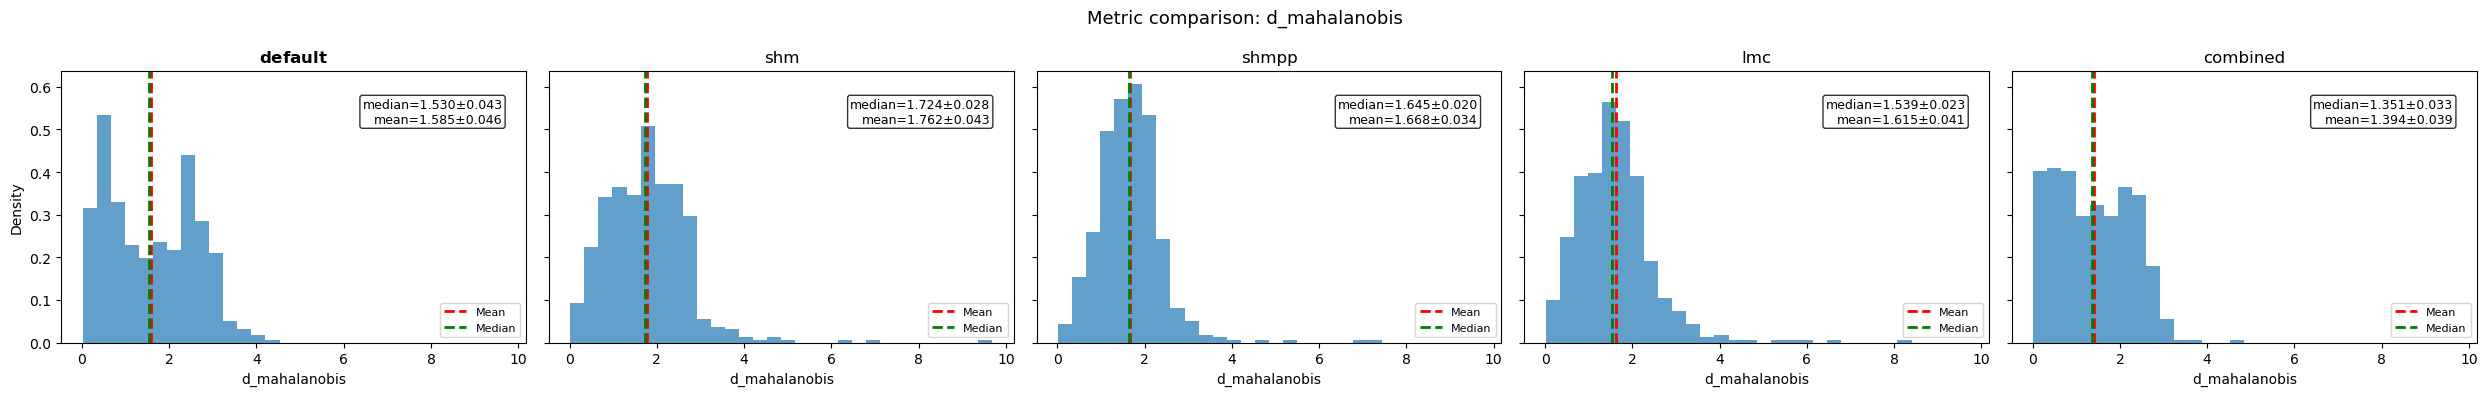

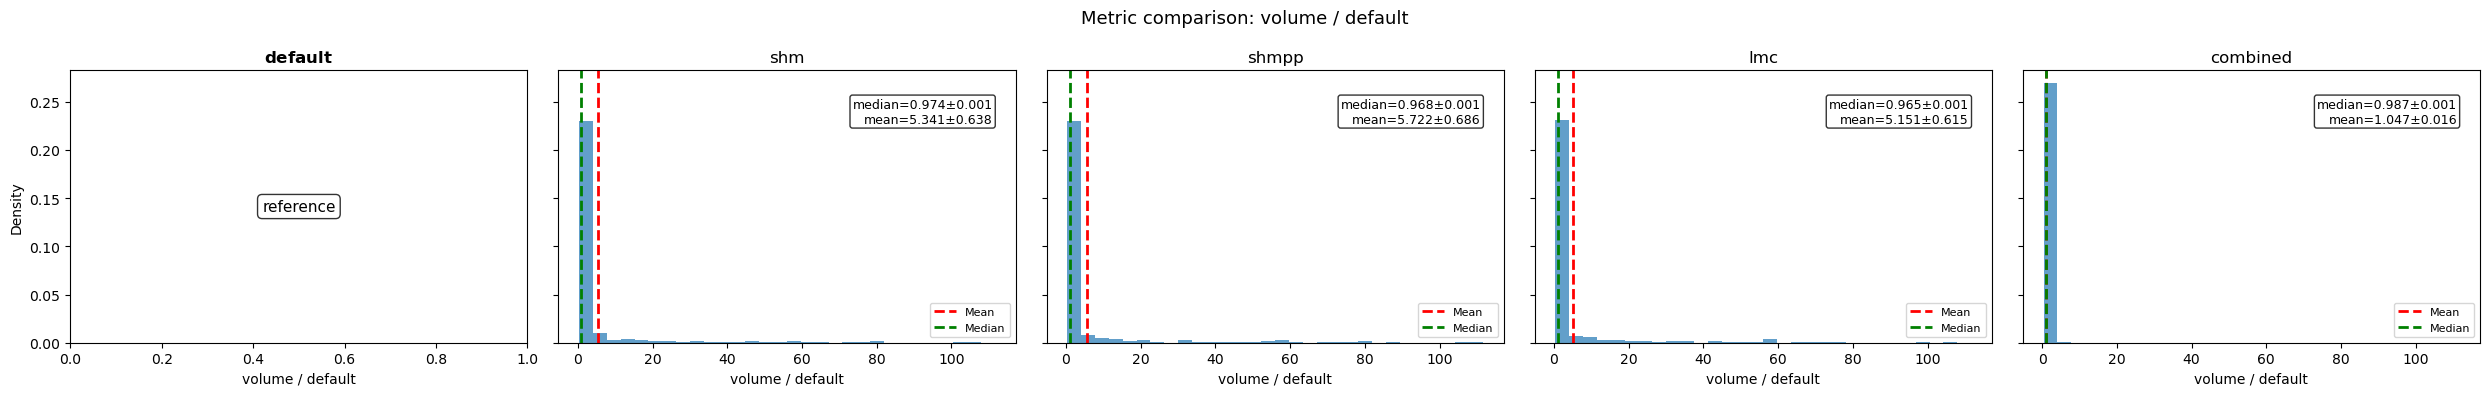

In [12]:
# ==========================================================
# Compare metric distributions (focused parameter window)
# ==========================================================

print("Comparing metric distributions (focused window)...\n")

for metric in ["d_euclidean", "d_mahalanobis", "volume"]:
    compare_metric_histograms(
        performances_windowed,
        metric=metric,
        bins=30,
        reference_label=halo_choice,
    )

Left to do:

- Run with and without background (Problem with background: Exclusionplots cannot easily be removed, distance measures are not really defined in a sensible way anymore)
- Compare with X1X2?
- Add default 